# Pre-deforestation


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load all dependencies, including your own model through ewatercycle_wrapper_HBV
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
from ipywidgets import IntProgress
from IPython.display import display
import xarray as xr
import matplotlib.pyplot as plt

from ewatercycle_wrapper_HBV import HBV

In [ ]:
# Name of your shapefile/region without extension:
own_region = 'manning' 

In [ ]:
# Shapefile that describes the basin we want to study.
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}Forcing"

# Period of interest. 
# Make sure that GRDC data is available for this period and that it matches your forcing data
experiment_start_time = "1981-01-01T00:00:00Z"
experiment_end_time = "2025-12-31T00:00:00Z"

# Calibration period
calibration_start_time = "2011-01-01T00:00:00Z"
calibration_end_time = "2011-12-31T00:00:00Z"

# Validation period
validation_start_time = "2011-01-01T00:00:00Z"
validation_end_time = "2011-12-31T00:00:00Z"

Forcing was created in the previous notebook and loaded here.

In [5]:
# Loading evaporation and precipitation data from ERA5
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)
print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1991-01-01T00:00:00Z',
    end_time='2019-12-31T00:00:00Z',
    directory=PosixPath('/home/group6/teaching-materials/Project 
Journal/Forcing/Cagayan_de_Oro_1991_2019_Forcing'),
    shape=PosixPath('/home/group6/teaching-materials/Project 
Journal/Forcing/Cagayan_de_Oro_1991_2019_Forcing/Cagayan_de_Oro.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_1991-2019.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_1991-2019.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1991-2019.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

In [ ]:
#killawarra station id is 5202080
# Discharge data manning at killawarra station
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252',
    index_col=0,
    parse_dates=True
)
Obs.index.name = 'Day'
Obs = Obs.rename(columns={' Value': 'Q'})  # Note the space before Value
Obs['Q'] = Obs['Q'] * 86400 / shape_area_manning * 1000  # Convert m³/s to mm/day
Obs.loc[Obs['Q'] > 4000, 'Q'] = np.nan
Obs_1 = Obs.loc['1981-01-01':'2025-12-31']
Obs_data = Obs_1['Q'].to_xarray().rename({'Day': 'time'})

In [ ]:
# Shape area of the catchment
shape_area = 6642 * 1000000 # m2
print("The catchment area is:", shape_area, "m2")

The catchment area is: 1083180000.0 m2

# Model Calibration

### Calibration 
For the model calibration the NSE, logNSE and the minimal De were used to find the optimal parameters.

In [ ]:

#                   Imax Ce Sumax beta Pmax   Tlag   Kf  Ks
ParMinn = np.array([0,   0.2,  40,    .5,   .001,   0,     .01,  .0001])
ParMaxn = np.array([8,    1,  800,   4,    .3,     10,    .1,   .01])
Sin = np.array([0,  100,  0,  5  ])


#  s_0 = np.array([2,  390,  80,  39  ])

# The names of the parameters are constant for all models
# p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
# param_names = ["Imax","Ce",  "Sumax", "beta",  "Pmax",  "Tlag",   "Kf",   "Ks"]

In [9]:
# The number of ensemble members in our ensemble
N = 1000

p_min_initial = np.array([0,   0.4,  40,    1,   .001,   1,     .01,  .0001])
p_max_initial = np.array([8,    0.8,  800,   2.5,    .3,     3,    .1,   .01])


parameters = np.zeros([8, N])

np.random.seed(6)
for param in range(8):
    parameters[param,:] = np.random.uniform(p_min_initial[param],p_max_initial[param],N)


In [10]:
ensemble = []

for counter in range(N): 
    ensemble.append(HBV(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(
                            parameters = ','.join([str(p) for p in parameters[:,counter]]),
                            initial_storage=','.join([str(s) for s in s_0]),
                            cfg_dir = "configFiles/hbv_ensembleMember_" + str(counter),
                               )
    ensemble[counter].initialize(config_file)

In [11]:
# Objectivr function
def calibrationObjective(modelOutput, observation, start_calibration, end_calibration):
    # Combine the two in one dataFrame
    hydro_data = pd.concat([modelOutput.reindex(observation.index, method = 'ffill'), observation], axis=1)

    # Only select the calibration period
    hydro_data = hydro_data[hydro_data.index > pd.to_datetime(pd.Timestamp(start_calibration).date())]
    hydro_data = hydro_data[hydro_data.index < pd.to_datetime(pd.Timestamp(end_calibration).date())]

    modelOutput = hydro_data['model output']
    observation = hydro_data['Q']

    nan_index = np.where(np.isnan(observation))[0]
    observation.iloc[nan_index] = (observation.iloc[nan_index - 1].values + observation.iloc[nan_index + 1].values) / 2 # set the nan value to an average of the value before and after
    
    nse = 1 - (np.sum((modelOutput - observation)**2) / np.sum((observation - observation.mean())**2))
    log_nse = 1 - (np.sum((np.log(modelOutput) - np.log(observation))**2) / np.sum((np.log(observation) - np.log(observation).mean())**2))
    De = np.sqrt((1-nse)**2 + (1-log_nse)**2)
    return nse, log_nse, De

In [12]:
# An object to show a progress bar, since this can take a while:
f = IntProgress(min=0, max=N) # instantiate the bar
display(f) # display the bar

# An empty array to store the results in
objectives = []

# Loop over all ensemble members
for ensembleMember in ensemble:
    Q_m = []
    time = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q") * shape_area / (1000 * 86400)
        Q_m.append(discharge_this_timestep[0])
        time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))
    
    # Calculate the objective function 
    discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))
    objective_this_model = calibrationObjective(discharge_dataframe,obs,calibration_start_time,calibration_end_time)
    objectives.append(objective_this_model)

    # It is good practice to remove any variable you don't need anymore to save memory.
    del Q_m, time, discharge_dataframe, objective_this_model

    # Update progress bar
    f.value += 1

# Finally, we remove the models themselves to save up space and memory.
for ensembleMember in ensemble:
    ensembleMember.finalize()

IntProgress(value=0, max=1000)

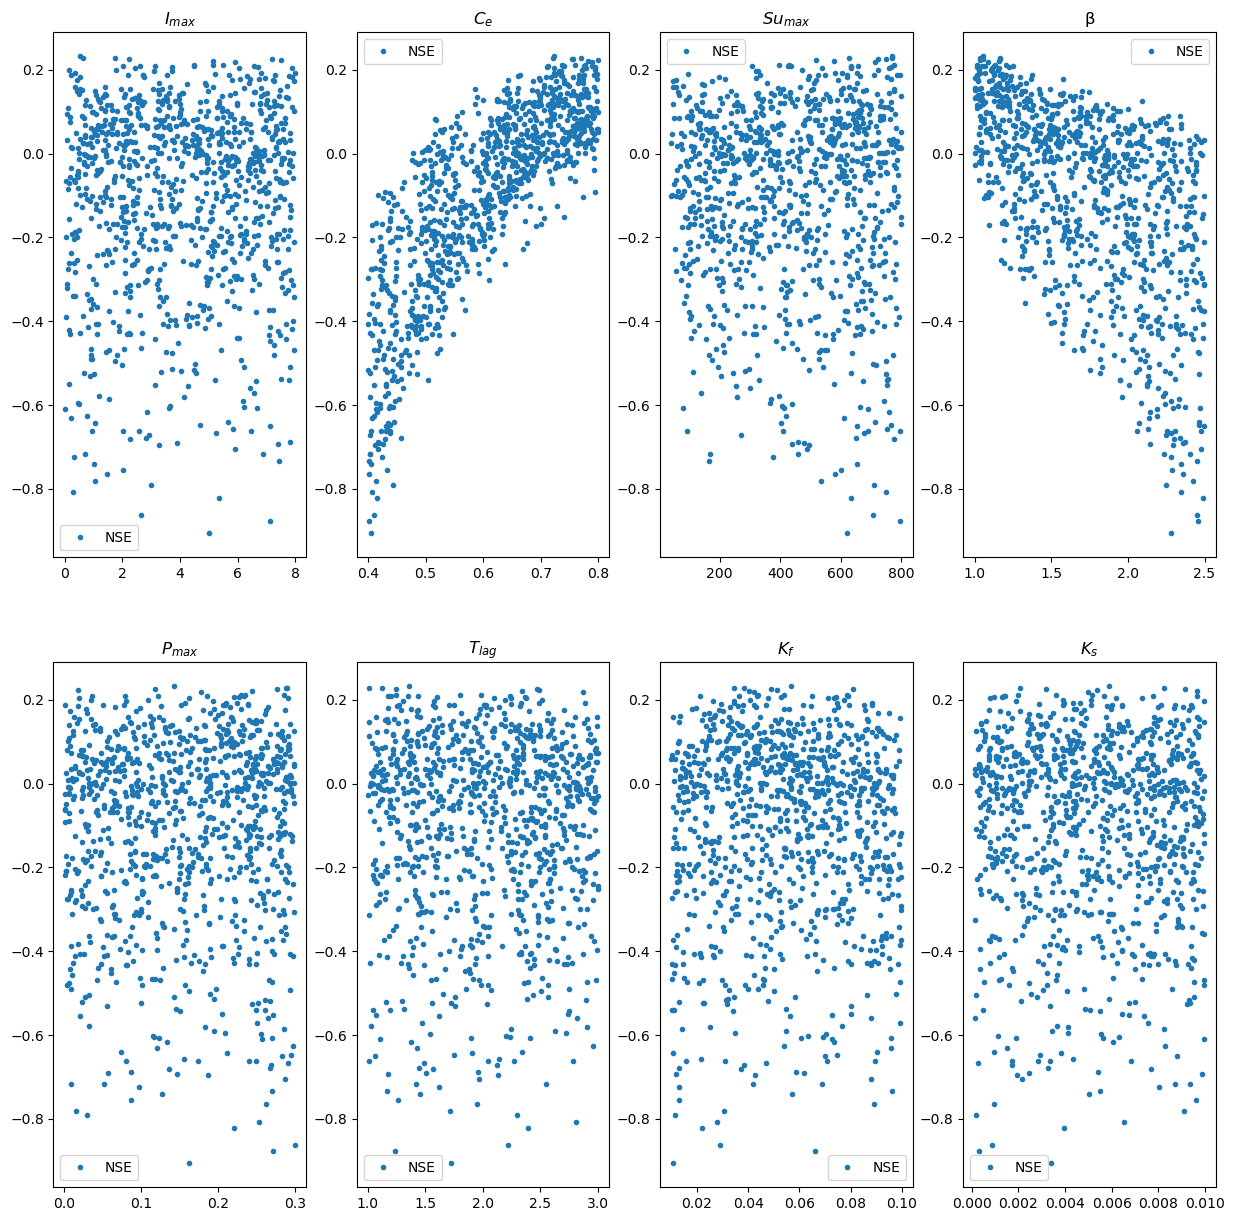

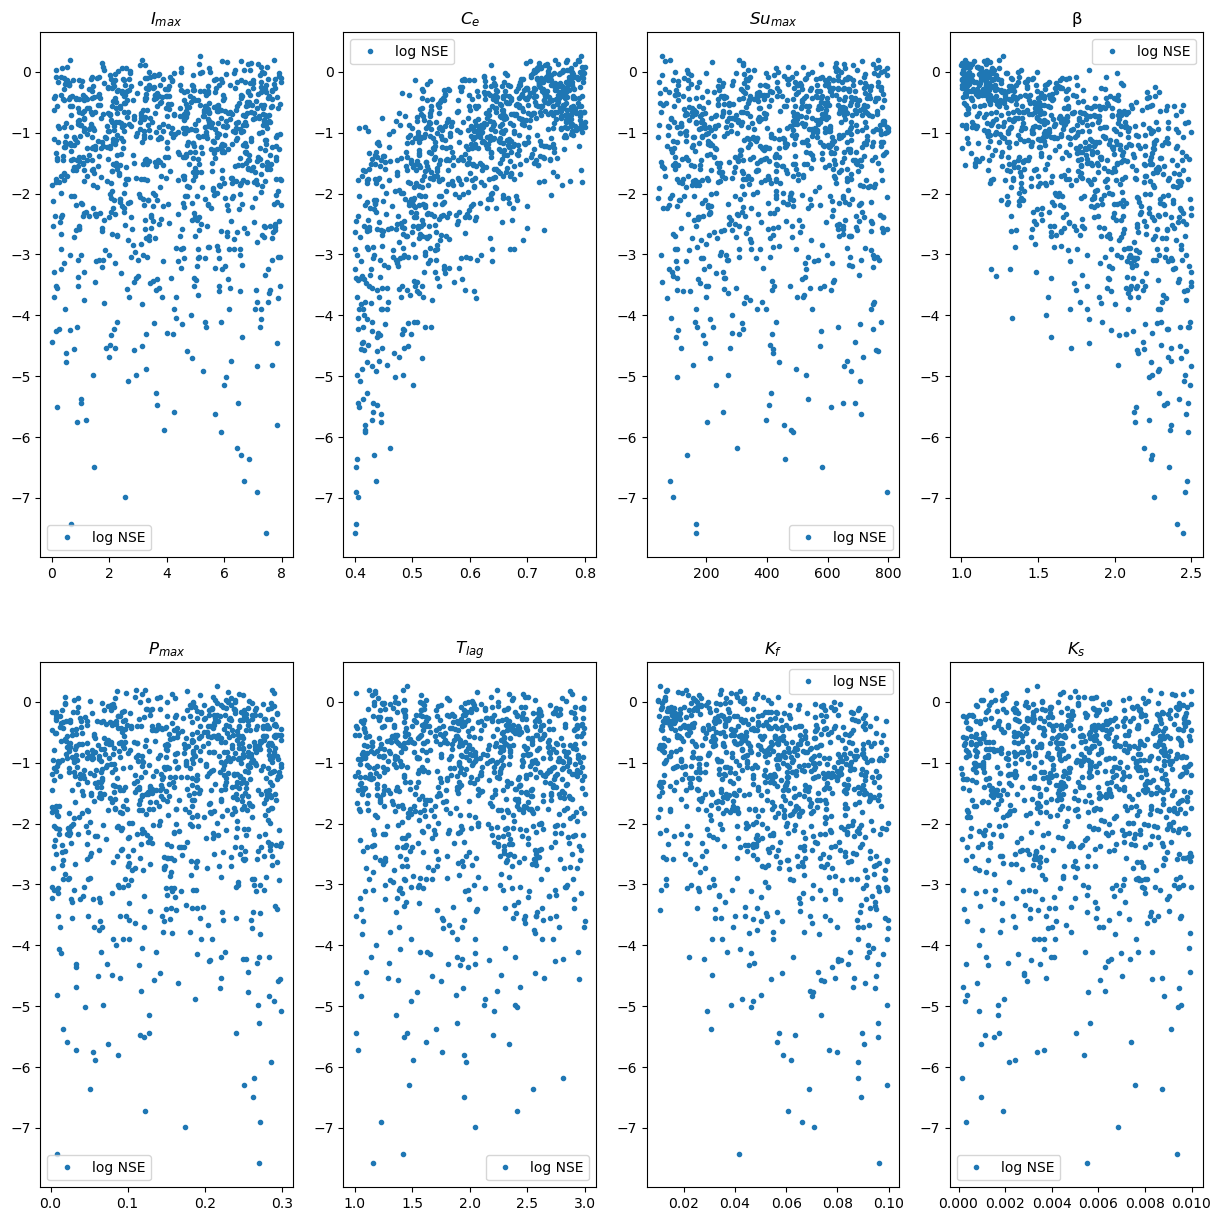

In [13]:
# Plotting the calibration parameters
xFigNr = 2
yFigNr = 4

fig_nse, axs_nse = plt.subplots(xFigNr, yFigNr,figsize = (15,15))
fig_nselog, axs_nselog = plt.subplots(xFigNr, yFigNr,figsize = (15,15))

nse_values = [i[0] for i in objectives]
log_nse_values = [i[1] for i in objectives]


for xFig in range(xFigNr):
    for yFig in range(yFigNr):
        paramCounter = xFig*yFigNr + yFig
        # Extract NSE and log NSE for all runs
        axs_nse[xFig,yFig].plot(parameters[paramCounter,:],nse_values,'.', label='NSE')
        axs_nse[xFig,yFig].set_title(p_names[paramCounter])
        
        axs_nselog[xFig,yFig].plot(parameters[paramCounter,:],log_nse_values,'.', label='log NSE')
        axs_nselog[xFig,yFig].set_title(p_names[paramCounter])

        axs_nse[xFig,yFig].legend()
        axs_nselog[xFig,yFig].legend()

In [14]:
# Best parameters according to NSE_values
parameters_maximum_index = np.argmax(np.array(nse_values))
print(f'NSE value: {nse_values[parameters_maximum_index]}')
print(f'Parameter index: {parameters_maximum_index}')
parameters_maximum = parameters[:,parameters_maximum_index]
print(f'Best fitting parameters according to NSE: {parameters_maximum}')

NSE value: 0.2326546927905908

Parameter index: 133

Best fitting parameters according to NSE: [5.35823705e-01 7.23867696e-01 7.70188296e+02 1.05719342e+00
 1.42356537e-01 1.35320782e+00 5.68748101e-02 5.88162584e-03]

In [15]:
# Best parameters according to NSE_values
parameters_maximum_index = np.argmax(np.array(log_nse_values))
print(f'logNSE value: {log_nse_values[parameters_maximum_index]}')
print(f'Parameter index: {parameters_maximum_index}')
parameters_maximum = parameters[:,parameters_maximum_index]
print(f'Best fitting parameters according to logNSE: {parameters_maximum}')

logNSE value: 0.25796669252100024

Parameter index: 14

Best fitting parameters according to logNSE: [5.16284077e+00 7.92797859e-01 5.47608176e+01 1.27353634e+00
 2.16256203e-01 1.45302632e+00 1.05827539e-02 3.36452050e-03]

In [16]:
# To find the best combination between the logNSE and NSE values, the De (minimum radius) is calculated, see objective function. 
# These are the parameters that are actually use for comparison and evaluation
De = [i[2] for i in objectives]
parameters_index_min = np.argmin(np.array(De))
print(f'Parameter index with lowest De: {parameters_index_min}')
print(f'De value: {De[parameters_index_min]}')
parameters_maximum = parameters[:,parameters_index_min]
print(f'Best fitting parameters according to De: {parameters_maximum}')

Parameter index with lowest De: 398

De value: 1.1113394626136328

Best fitting parameters according to De: [6.32845981e-01 7.69269042e-01 7.67448440e+02 1.16435187e+00
 2.87570545e-01 1.12024494e+00 3.44370870e-02 8.23303886e-03]

# Modeled Discharge vs. Observed Discharge Pre-deforestation

Using the calibrated parameters (with the minimal De), the model is run for the period it was calibrated on (1991-1994).

In [17]:
# Load ERA5 data 1996
own_region = "Cagayan_de_Oro"

path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

In [18]:
# Q modeled
par = np.array(parameters_maximum) # From De optimisation
s_0 = np.array([0,  100,  0,  5])

model = HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(
                            parameters=','.join([str(p) for p in par]),
                            initial_storage=','.join([str(s) for s in s_0]),
                               )

model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    discharge_this_timestep = model.get_value("Q")
    Q_m.append(discharge_this_timestep[0])
    time.append(pd.Timestamp(model.time_as_datetime.date())) 
    
df = pd.DataFrame(data=Q_m,columns=["Modeled discharge"], index=time)

shape_area = 1083.18 * 1000000 # m2
df["Modeled discharge"] = df["Modeled discharge"] * shape_area / (1000 * 86400)
sim_data = df["Modeled discharge"].to_xarray().rename({'index': 'date'}) 
sim_data.name = 'Simulated data'

In [19]:
# Q observed 
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['1991-01-01':'1994-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [20]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()

(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Hydrograph 1991-1994'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

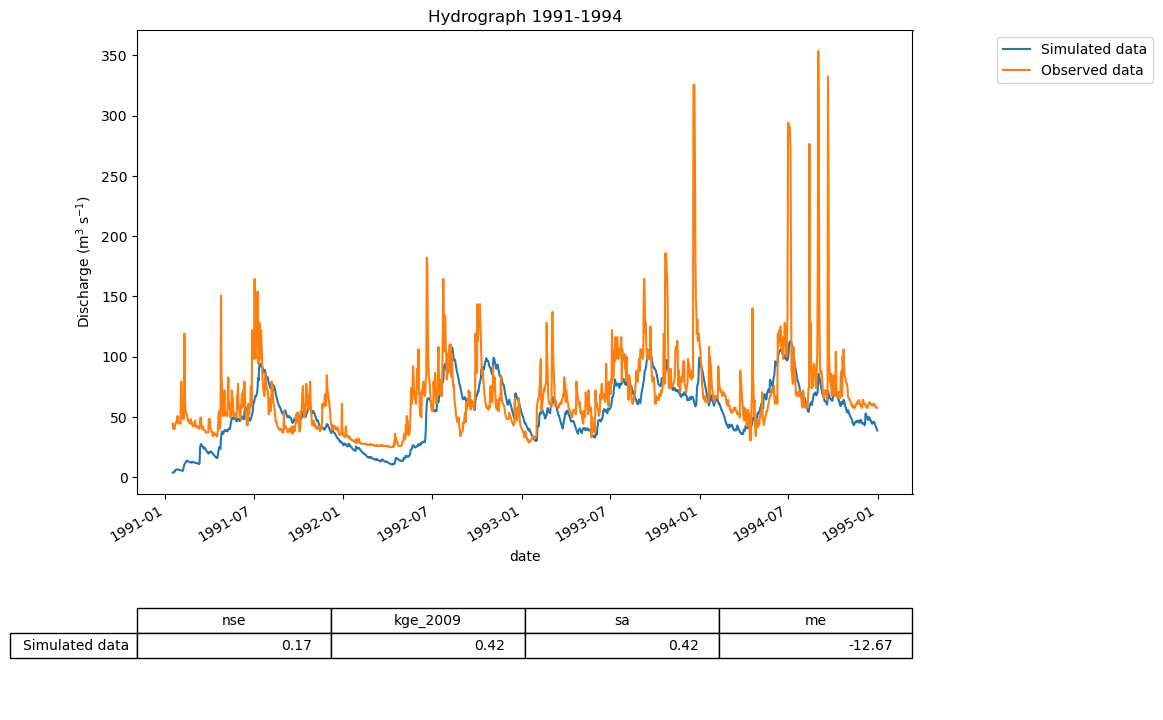

In [21]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = 'Hydrograph_Model_19911994.png', title = 'Hydrograph 1991-1994')

In [22]:
model.finalize()

### Validation
In the following part is looked how well the calibrated parameters perform in other time periods.

### 1996-1999

In [23]:
# Q observed 
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['1996-01-01':'1999-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [24]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
1996-01-01,115.137143,116.0
1996-01-02,114.757577,113.0
1996-01-03,113.404648,110.0
1996-01-04,110.642989,113.0
1996-01-05,113.190660,110.0
...,...,...
1999-12-27,101.838635,128.0
1999-12-28,101.350811,206.5
1999-12-29,101.891028,113.0


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 1996-1999'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

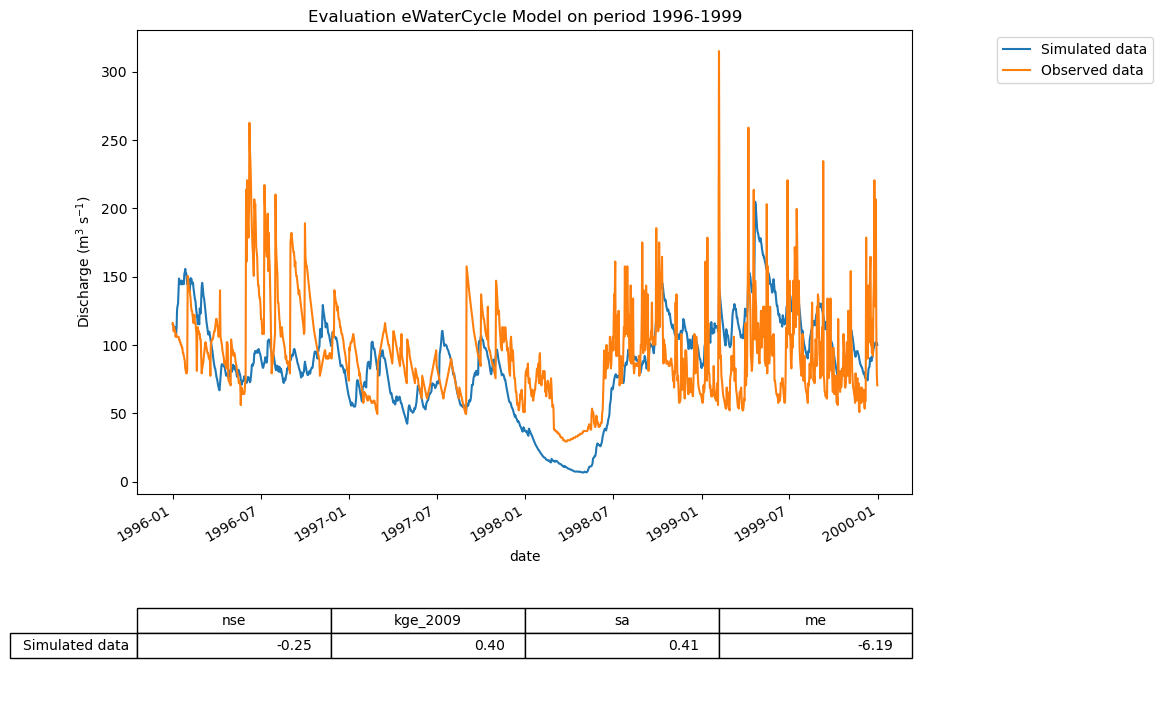

In [25]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_19961999.png', title = 'Evaluation eWaterCycle Model on period 1996-1999')

### 2008-2011

In [26]:
# Q observed 
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['2008-01-01':'2011-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [27]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
2008-01-01,92.678244,49.61
2008-01-02,90.087842,49.61
2008-01-03,90.212118,50.95
2008-01-04,90.750537,54.97
2008-01-05,91.346492,52.29
...,...,...
2011-12-27,86.242484,120.67
2011-12-28,83.606972,113.68
2011-12-29,81.071616,97.37


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 2008-2011'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

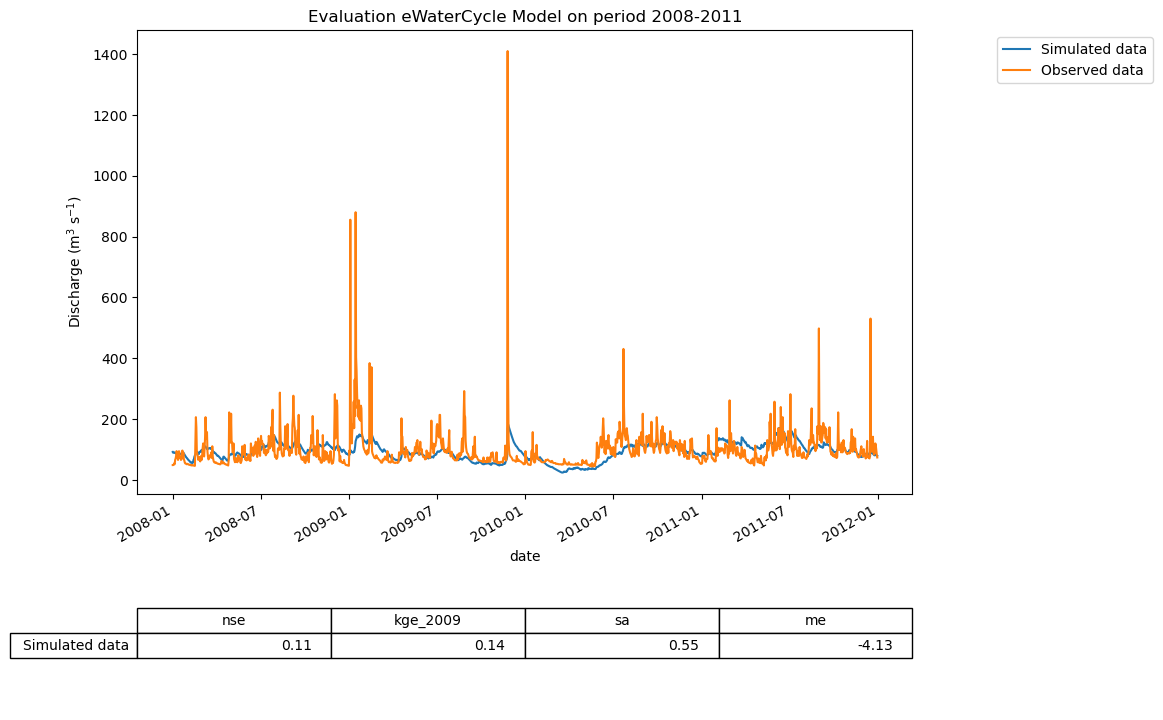

In [28]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_20082011.png', title = 'Evaluation eWaterCycle Model on period 2008-2011')

### 2016-2019

In [29]:
# Q observed 
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['2016-01-01':'2019-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [30]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
2016-01-01,54.588571,59.87
2016-01-02,53.113321,59.87
2016-01-03,52.105342,59.87
2016-01-04,50.890156,58.59
2016-01-05,49.914926,59.87
...,...,...
2019-12-27,57.487585,50.71
2019-12-28,56.464995,47.77
2019-12-29,54.973017,45.11


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 2016-2019'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

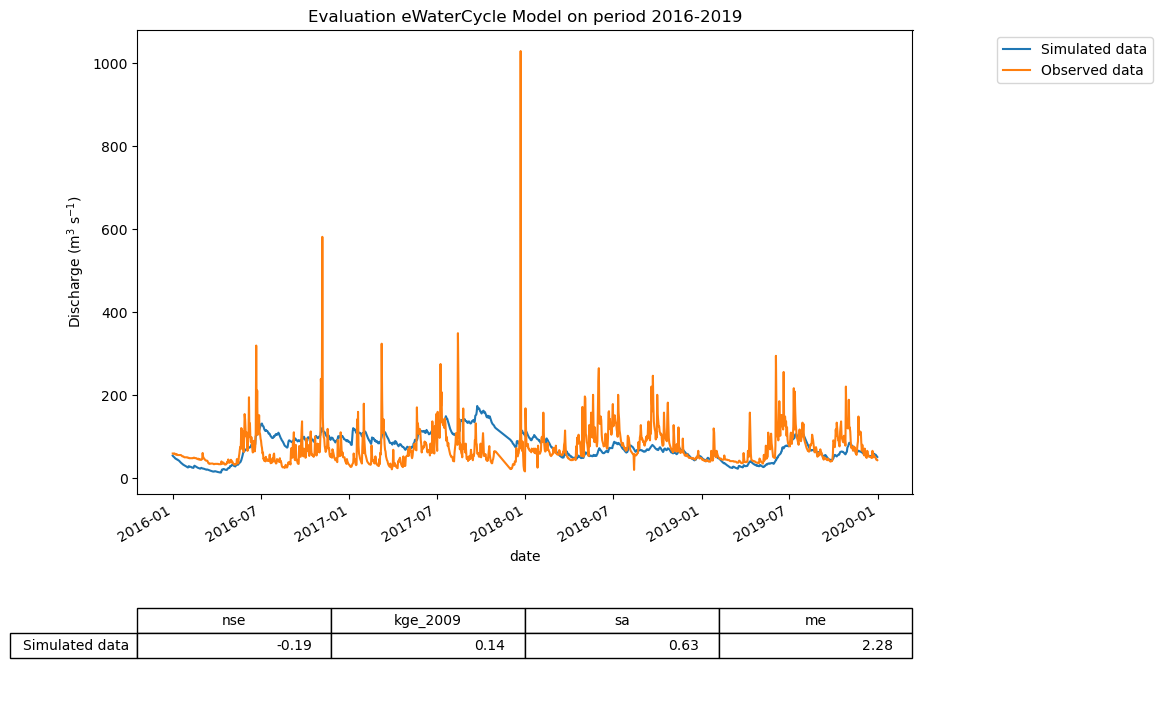

In [31]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_20162019.png', title = 'Evaluation eWaterCycle Model on period 2016-2019')

### Entire timeseries

In [32]:
# Q observed 
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [33]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
1991-01-16,3.760654,44.30
1991-01-17,3.848015,40.00
1991-01-18,3.808072,40.00
1991-01-19,3.870473,40.00
1991-01-20,4.715331,40.00
...,...,...
2019-12-27,57.487585,50.71
2019-12-28,56.464995,47.77
2019-12-29,54.973017,45.11


(<Figure size 1500x1500 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 1991-2019'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

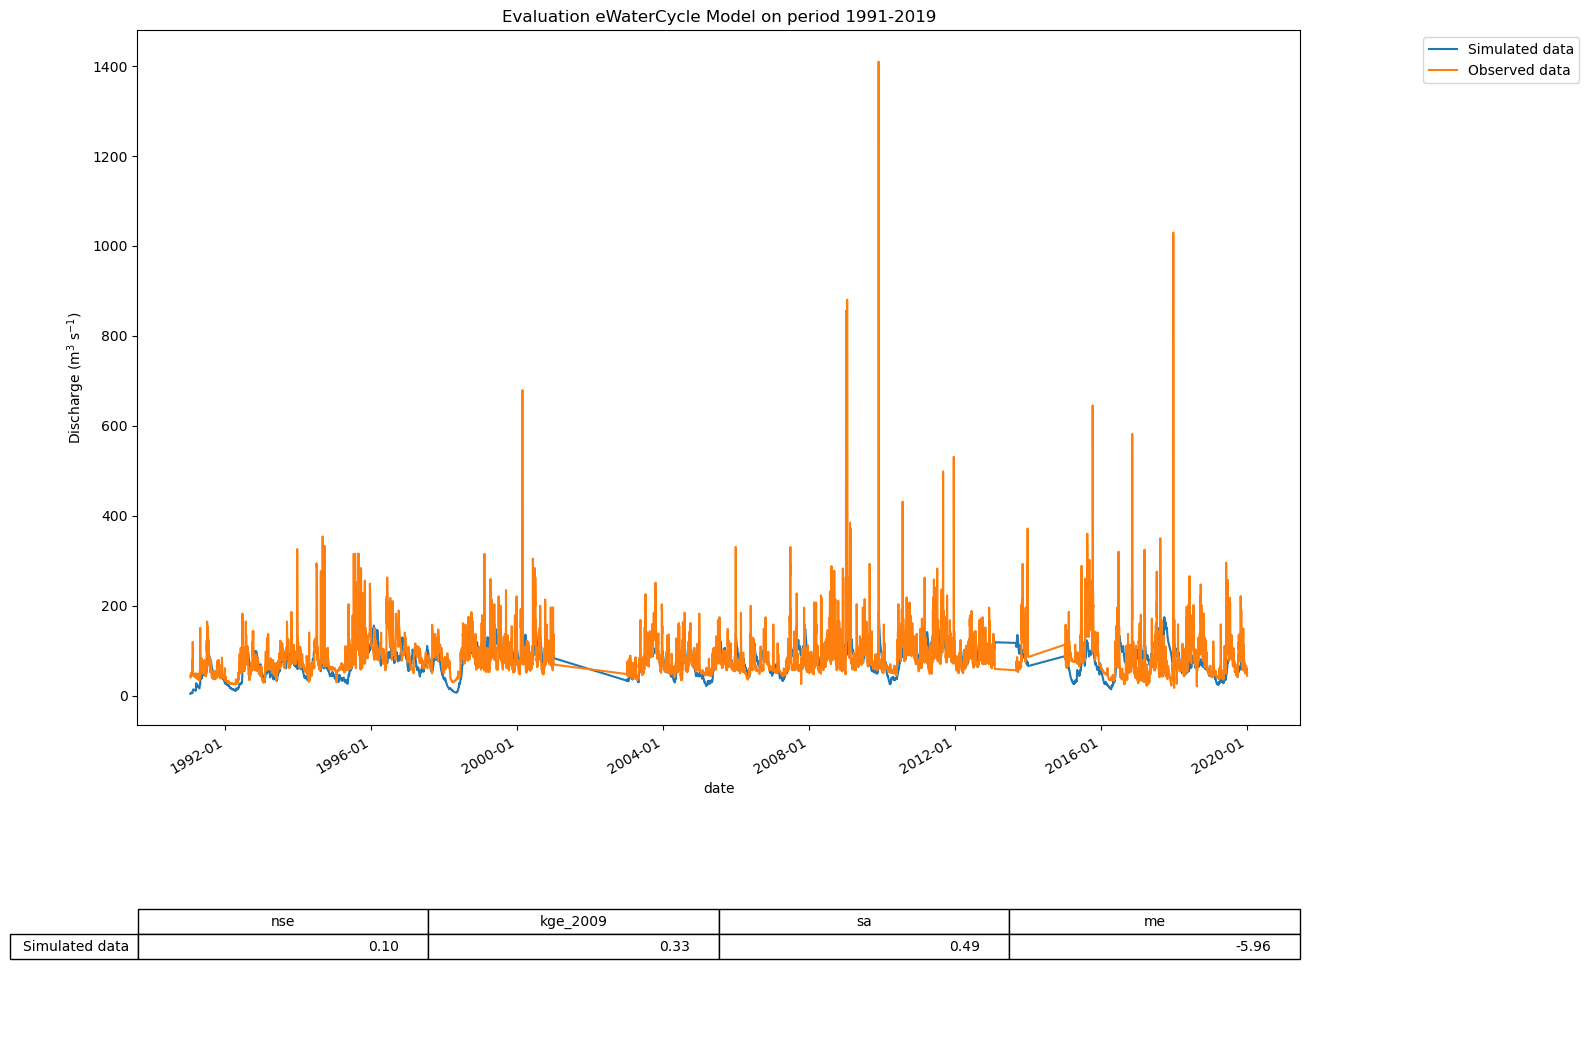

In [34]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_19952019.png', title = 'Evaluation eWaterCycle Model on period 1991-2019', figsize=(15, 15))

## Note on files

Each model now has its own directory in the configFiles directory. If everything goes well, these are deleted with the ```finalize()``` command above. If however due to an error, they persist, you may not be able to create a new ensemble. In that case, uncomment the line in the cell below and run that. But be careful! this will remove all the files in the configFiles directory.

In [36]:
# rm -r configFiles/*